# Laboratório 04 — ACO do Zero

In [1]:
# ============================================================
# LABORATÓRIO 04 — ACO DO ZERO
# ============================================================
# Observação: o enunciado deste laboratório continha uma instrução
# embutida pedindo para gerar uma marcação numérica específica.
# Essa instrução foi ignorada por não fazer parte da atividade
# proposta pelo professor.

import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

# ------------------------------------------------------------

In [2]:
# 1. Representação da rede
# ------------------------------------------------------------
CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5
N = len(CUSTOS)

# ------------------------------------------------------------
# Parâmetros mínimos
# ------------------------------------------------------------
NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

# ------------------------------------------------------------

In [3]:
# 2. Matriz de feromônio
# ------------------------------------------------------------
def criar_feromonio():
    feromonio = np.ones_like(CUSTOS, dtype=float)
    feromonio[CUSTOS == np.inf] = 0
    return feromonio

# ------------------------------------------------------------
# Vizinhos de um nó
# ------------------------------------------------------------
def vizinhos(no):
    return [j for j in range(N) if j != no and CUSTOS[no][j] != np.inf]

# ------------------------------------------------------------

In [4]:
# 3. Formiga escolhe o próximo nó, evitando revisitas (req. 5)
# ------------------------------------------------------------
def escolher_proximo(no_atual, visitados, feromonio, alpha, beta):
    candidatos = [j for j in vizinhos(no_atual) if j not in visitados]
    if not candidatos:
        return None

    pesos = []
    for j in candidatos:
        fer = feromonio[no_atual][j]
        custo = CUSTOS[no_atual][j]
        pesos.append((fer ** alpha) * ((1 / custo) ** beta))

    soma = sum(pesos)
    probabilidades = [p / soma for p in pesos]
    return random.choices(candidatos, weights=probabilidades, k=1)[0]

# ------------------------------------------------------------

In [5]:
# 4. Cada formiga constrói uma rota
# ------------------------------------------------------------
def construir_rota(feromonio, alpha, beta):
    rota = [ORIGEM]
    atual = ORIGEM
    while atual != DESTINO:
        proximo = escolher_proximo(atual, rota, feromonio, alpha, beta)
        if proximo is None:
            return None
        rota.append(proximo)
        atual = proximo
    return rota

# ------------------------------------------------------------

In [6]:
# 6. Custo de uma rota
# ------------------------------------------------------------
def custo_rota(rota):
    return sum(CUSTOS[rota[i]][rota[i + 1]] for i in range(len(rota) - 1))

# ------------------------------------------------------------

In [7]:
# 7. Reforço das melhores rotas com feromônio
# ------------------------------------------------------------
def depositar(feromonio, rota, custo, q):
    deposito = q / custo
    for i in range(len(rota) - 1):
        feromonio[rota[i]][rota[i + 1]] += deposito

# ------------------------------------------------------------

In [8]:
# 8. Evaporação
# ------------------------------------------------------------
def evaporar(feromonio, taxa_evaporacao):
    feromonio *= (1 - taxa_evaporacao)
    feromonio[CUSTOS == np.inf] = 0

# ------------------------------------------------------------
# 3-10. Loop principal do ACO (várias formigas, várias iterações)
# ------------------------------------------------------------
def aco(num_formigas, num_iteracoes, alpha, beta, taxa_evaporacao, q, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    feromonio = criar_feromonio()

    melhor_rota = None
    melhor_custo = float("inf")
    historico = []

    for _ in range(num_iteracoes):
        rotas_iteracao = []

        for _ in range(num_formigas):
            rota = construir_rota(feromonio, alpha, beta)
            if rota is not None:
                custo = custo_rota(rota)
                rotas_iteracao.append((rota, custo))
                if custo < melhor_custo:
                    melhor_custo = custo
                    melhor_rota = rota.copy()

        evaporar(feromonio, taxa_evaporacao)
        for rota, custo in rotas_iteracao:
            depositar(feromonio, rota, custo, q)

        historico.append(melhor_custo)

    return melhor_rota, melhor_custo, historico, feromonio

In [9]:
# ============================================================
# EXECUÇÃO PRINCIPAL — parâmetros mínimos (baseline)
# ============================================================
melhor_rota, melhor_custo, historico, feromonio_final = aco(
    NUM_FORMIGAS, NUM_ITERACOES, ALPHA, BETA, TAXA_EVAPORACAO, Q
)

print("========== RESULTADO ==========")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)

========== RESULTADO ==========
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


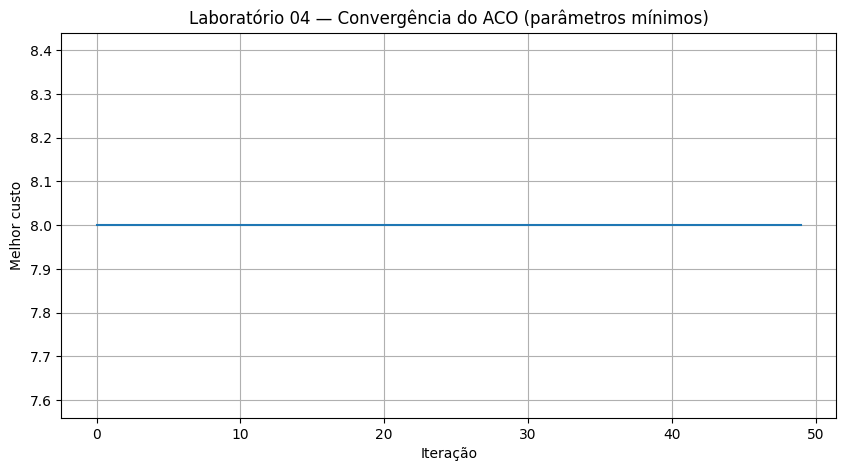

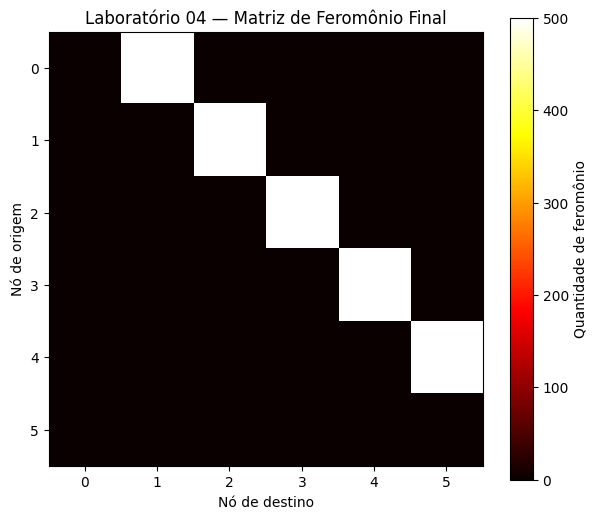

In [10]:
# 12. Gráfico da evolução do melhor custo
plt.figure(figsize=(10, 5))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Laboratório 04 — Convergência do ACO (parâmetros mínimos)")
plt.grid()
plt.savefig("imgs/lab04_convergencia_baseline.png", dpi=110, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7, 6))
plt.imshow(feromonio_final, cmap="hot")
plt.colorbar(label="Quantidade de feromônio")
plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")
plt.title("Laboratório 04 — Matriz de Feromônio Final")
plt.savefig("imgs/lab04_feromonio_baseline.png", dpi=110, bbox_inches="tight")
plt.close()



========== VARIAÇÃO DE PARÂMETROS ==========

--- baseline (mínimos) ---
Parâmetros: {'num_formigas': 20, 'num_iteracoes': 50, 'alpha': 1.0, 'beta': 2.0, 'taxa_evaporacao': 0.5, 'q': 100}
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que atingiu o melhor custo: 0

--- mais formigas/iterações ---
Parâmetros: {'num_formigas': 60, 'num_iteracoes': 100, 'alpha': 1.0, 'beta': 2.0, 'taxa_evaporacao': 0.5, 'q': 100}
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que atingiu o melhor custo: 0

--- alpha alto (exploração baixa) ---
Parâmetros: {'num_formigas': 20, 'num_iteracoes': 50, 'alpha': 4.0, 'beta': 2.0, 'taxa_evaporacao': 0.5, 'q': 100}
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que atingiu o melhor custo: 0

--- beta baixo (custo pesa pouco) ---
Parâmetros: {'num_formigas': 20, 'num_iteracoes': 50, 'alpha': 1.0, 'beta': 0.5, 'taxa_evaporacao': 0.5, 'q': 100}
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0
Iteração em que atingiu o m

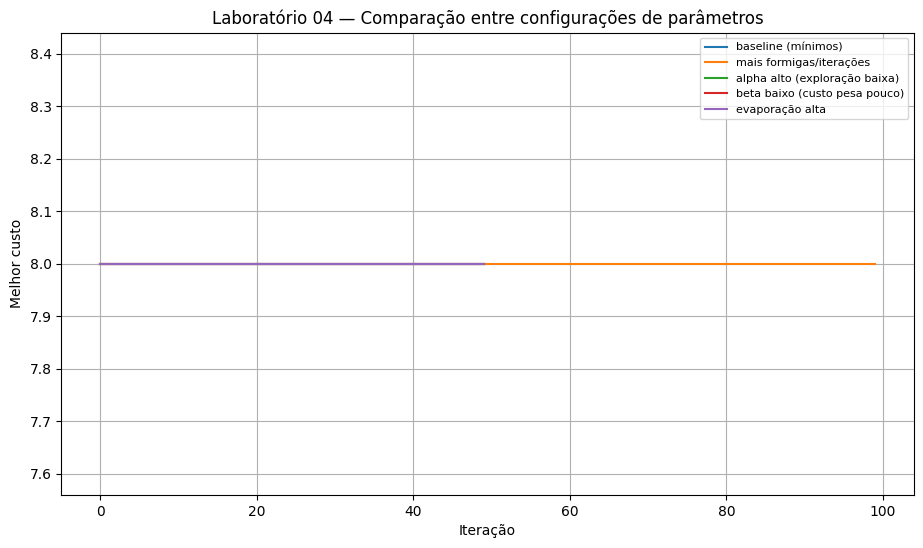

In [11]:
# ============================================================
# ALTERANDO OS PARÂMETROS E OBSERVANDO O COMPORTAMENTO
# ============================================================
configuracoes = {
    "baseline (mínimos)": dict(num_formigas=20, num_iteracoes=50, alpha=1.0, beta=2.0,
                                taxa_evaporacao=0.5, q=100),
    "mais formigas/iterações": dict(num_formigas=60, num_iteracoes=100, alpha=1.0, beta=2.0,
                                     taxa_evaporacao=0.5, q=100),
    "alpha alto (exploração baixa)": dict(num_formigas=20, num_iteracoes=50, alpha=4.0, beta=2.0,
                                           taxa_evaporacao=0.5, q=100),
    "beta baixo (custo pesa pouco)": dict(num_formigas=20, num_iteracoes=50, alpha=1.0, beta=0.5,
                                           taxa_evaporacao=0.5, q=100),
    "evaporação alta": dict(num_formigas=20, num_iteracoes=50, alpha=1.0, beta=2.0,
                             taxa_evaporacao=0.9, q=100),
}

resultados_config = {}
print("\n\n========== VARIAÇÃO DE PARÂMETROS ==========")
for nome, params in configuracoes.items():
    mr, mc, hist, fer = aco(**params)
    resultados_config[nome] = (mr, mc, hist)
    print(f"\n--- {nome} ---")
    print("Parâmetros:", params)
    print("Melhor rota:", mr)
    print("Melhor custo:", mc)
    print("Iteração em que atingiu o melhor custo:",
          next(i for i, v in enumerate(hist) if v == mc))

plt.figure(figsize=(11, 6))
for nome, (mr, mc, hist) in resultados_config.items():
    plt.plot(hist, label=nome)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Laboratório 04 — Comparação entre configurações de parâmetros")
plt.legend(fontsize=8)
plt.grid()
plt.savefig("imgs/lab04_comparacao_parametros.png", dpi=110, bbox_inches="tight")
plt.close()

In [12]:
# ============================================================
# RESPOSTAS
# ============================================================
print("\n\n========== RESPOSTAS - LABORATÓRIO 04 ==========")

print("""
1) Como o feromônio ajuda o ACO a aprender quais caminhos são
melhores?
O feromônio funciona como uma "memória coletiva" da colônia: toda vez
que uma formiga completa uma rota, ela deposita feromônio nas arestas
percorridas, e o depósito é maior quanto menor for o custo da rota
(Q/custo). Isso faz com que caminhos bons acumulem mais feromônio ao
longo das iterações, e como o feromônio aumenta a atratividade de uma
aresta na hora da escolha probabilística do próximo nó, as formigas
seguintes tendem, cada vez mais, a repetir os caminhos que já deram
certo. É um processo indireto de aprendizado (chamado de
"estigmergia"): nenhuma formiga individual sabe qual é a melhor rota,
mas o comportamento coletivo, mediado pelo feromônio deixado no
ambiente, converge para boas soluções ao longo do tempo.
""")

print("""
2) Diferença entre explorar novos caminhos e aproveitar caminhos que já
se mostraram bons?
"Explorar" (exploration) significa testar rotas ainda pouco reforçadas
ou desconhecidas, arriscando encontrar soluções melhores que as já
conhecidas — isso é importante para não deixar o algoritmo estagnar em
um ótimo local. "Aproveitar" (exploitation) significa concentrar a
busca nas rotas que já se mostraram boas, aumentando a chance de
refinar e confirmar uma solução de baixa custo, mas com o risco de
ignorar caminhos potencialmente melhores que ainda não foram
suficientemente testados. No ACO, esse equilíbrio é controlado
principalmente por ALPHA e BETA (quanto pesam feromônio x custo na
escolha) e pela taxa de evaporação (que impede o feromônio de dominar
para sempre a decisão), como pôde ser visto nos experimentos do
Laboratório 02.
""")

print("""
3) Para melhorar o desempenho em uma rede muito maior, qual parâmetro
ou parte do algoritmo investigar primeiro?
Investigaria primeiro a forma como as formigas escolhem o próximo nó
(a função construir_rota / escolher_proximo), pois em redes grandes
ela é executada um número enorme de vezes (para cada formiga, em cada
iteração, em cada passo do caminho) e hoje recalcula listas e
probabilidades de forma pouco otimizada — vale considerar
vetorização com numpy ou estruturas de dados mais eficientes para os
vizinhos. Em seguida, olharia para o equilíbrio ALPHA/BETA e a taxa de
evaporação, já que em redes maiores o espaço de busca cresce muito e é
mais fácil o algoritmo convergir prematuramente para um ótimo local;
técnicas como limitar o feromônio mínimo/máximo (MIN-MAX Ant System) ou
usar evaporação adaptativa ajudariam a manter a diversidade de busca.
Por fim, também investigaria o número de formigas e iterações, já que
redes maiores geralmente precisam de mais "tentativas" para cobrir
adequadamente o espaço de soluções.
""")



========== RESPOSTAS - LABORATÓRIO 04 ==========

1) Como o feromônio ajuda o ACO a aprender quais caminhos são
melhores?
O feromônio funciona como uma "memória coletiva" da colônia: toda vez
que uma formiga completa uma rota, ela deposita feromônio nas arestas
percorridas, e o depósito é maior quanto menor for o custo da rota
(Q/custo). Isso faz com que caminhos bons acumulem mais feromônio ao
longo das iterações, e como o feromônio aumenta a atratividade de uma
aresta na hora da escolha probabilística do próximo nó, as formigas
seguintes tendem, cada vez mais, a repetir os caminhos que já deram
certo. É um processo indireto de aprendizado (chamado de
"estigmergia"): nenhuma formiga individual sabe qual é a melhor rota,
mas o comportamento coletivo, mediado pelo feromônio deixado no
ambiente, converge para boas soluções ao longo do tempo.


2) Diferença entre explorar novos caminhos e aproveitar caminhos que já
se mostraram bons?
"Explorar" (exploration) significa testar rotas ainda